# Practical Exercise 2 - Task 1
# Vanilla GAN on MNIST using PyTorch

In this notebook, we implement a simple Vanilla GAN to generate MNIST-like digit images.

We will:
1. Load the MNIST dataset
2. Build the Generator and Discriminator
3. Train the GAN
4. Visualize generated samples

In [ ]:
# Standard library imports
import os
import random
from pathlib import Path
from datetime import datetime

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb

import global_config as gc
from utils import device_check, show_generated_images, make_generated_figure, save_generated_grid, build_model_name
from GAN import Generator, Discriminator, train_GAN

## General setup

In [12]:
LOG_WANDB = False
SEED = 1

# Device setup
device = device_check()

# Reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Enable cuDNN auto-tuner for fixed-size inputs
    torch.backends.cudnn.benchmark = True
    # Data loading settings
    PIN_MEMORY = True
else:
    PIN_MEMORY = False

NUM_WORKERS = 16

PyTorch: 2.11.0+cpu | Python: 3.13.7 | OS: Windows 11
CUDA available: False
Using cpu


## Configuration

In [14]:
config = {
    "batch_size": 128,
    "latent_dim": 100,
    "g_hidden_dim": 128,
    "d_hidden_dim": 128,
    "image_dim": 28 * 28,
    "g_lr": 1e-3,
    "d_lr": 1e-3,
    "epochs": 100,
    "jupyter_plot_interval": 10,
    "wandb_image_interval": 1,
    "optimizer": "Adam",
    "betas": (0.9, 0.999),
    "dataset": "MNIST",
    "model": "Vanilla GAN",
    "seed": SEED
}

## Load MNIST dataset

In [16]:
# Transform pipeline for MNIST
transform = transforms.Compose([
    transforms.ToTensor() # ToTensor converts images to tensors in the range [0, 1]
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root=gc.DATA_DIR,
    train=True,
    transform=transform,
    download=True
)

# DataLoader handles batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 468


## Visualize a few real images

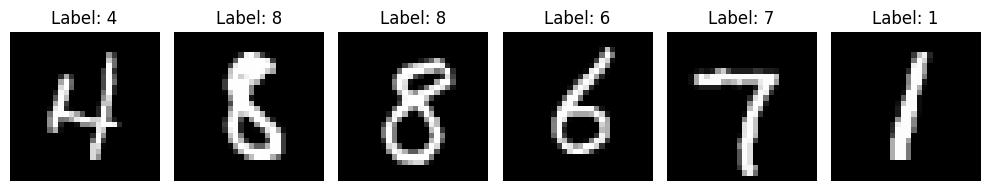

In [17]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Initialize models

In [18]:
G = Generator(
    z_dim=config["latent_dim"],
    h_dim=config["g_hidden_dim"],
    x_dim=config["image_dim"],
).to(device)

D = Discriminator(
    x_dim=config["image_dim"],
    h_dim=config["d_hidden_dim"],
).to(device)

print(G)
print()
print(D)

Generator(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=784, bias=True)
)

Discriminator(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


## Define the loss function and optimizers

In [19]:
# Binary cross entropy loss for Vanilla GAN
criterion = nn.BCELoss()

# Separate optimizers for Generator and Discriminator
g_optimizer = optim.Adam(
    G.parameters(),
    lr=config["g_lr"],
    betas=config["betas"]
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=config["d_lr"],
    betas=config["betas"]
)

## Train the Vanilla GAN

In [ ]:
train_GAN(
    G, D, criterion, train_loader,
    g_optimizer, d_optimizer,
    config, device,
    wandb_kwargs=dict(
        entity=gc.WANDB_ENTITY,
        project=gc.WANDB_PROJECT,
        name="Task1 - Vanilla GAN MNIST",
        tags=["Task 1", "MNIST", "Vanilla GAN"],
        dir=str(gc.WANDB_DIR),
        config=config,
        mode="online" if LOG_WANDB else "disabled",
    ),
    save_epochs={5, 10, 50, 100},
    out_dir=gc.OUT_DIR,
)

## Save trained models

In [25]:
# Save a full training checkpoint
checkpoint_name = build_model_name(config, task_name="task1")
checkpoint_path = gc.MODELS_DIR / checkpoint_name

torch.save({
    "task": "Task 1",
    "model_type": config["model"],
    "dataset": config["dataset"],
    "epoch": config["epochs"],
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "g_optimizer_state_dict": g_optimizer.state_dict(),
    "d_optimizer_state_dict": d_optimizer.state_dict(),
    "config": config,
    "device_used": str(device),
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")

Checkpoint saved to: C:\Users\Oscar\Projects\D7047E\Lab2\Models\task1_model-Vanilla_GAN_data-MNIST_ep-100_bs-128_glr-0.001_dlr-0.001_gh-128_dh-128_seed-1_20260420_195720.pt


In [26]:
# Save Generator weights only
generator_name = build_model_name(config, task_name="task1_generator")
generator_path = gc.MODELS_DIR / generator_name

torch.save(G.state_dict(), generator_path)

print(f"Generator weights saved to: {generator_path}")

Generator weights saved to: C:\Users\Oscar\Projects\D7047E\Lab2\Models\task1_generator_model-Vanilla_GAN_data-MNIST_ep-100_bs-128_glr-0.001_dlr-0.001_gh-128_dh-128_seed-1_20260420_195721.pt


## Display final generated samples

In [ ]:
show_generated_images(G, config["latent_dim"], device)